In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych i poprawne parsowanie czasu
# Używamy pd.to_datetime, aby poprawnie obliczyć dt w sekundach

dane_normalne = pd.read_excel("Przebieg normalny.xlsx")
dane_zaburzone = pd.read_excel("Przebieg zaburzony.xlsx")


dodanie wyświetlenia kolumn  i dodanie czasu z pliku a nie dt=1

In [37]:
dt = 1

def przygotuj_sygnaly(df):
    # Temperatury y i z dzielimy przez 10 (zgodnie z wytycznymi: 235 -> 23.5)
    temp_obiektu = df["y (T)"].values / 10.0
    temp_otoczenia = df["z (Tz)"].values / 10.0
    moc_grzalki = df["u (Pg)"].values
    return temp_obiektu, temp_otoczenia, moc_grzalki

y_norm, z_norm, u_norm = przygotuj_sygnaly(dane_normalne)
y_zab, z_zab, u_zab = przygotuj_sygnaly(dane_zaburzone)

In [38]:
# Zad 1 i 2: Wyznaczenie parametrów c i d metodą MNK
# Model dyskretny: y[n+1] = y[n] + (Δt/c)*u[n] + (d*Δt/c)*(z[n] - y[n])
# Równanie regresji:  y[n+1] -y[n] = a*u + b*(z-y)
# gdzie paramtery pomocnicze to: a = Δt/c, b = (d*Δt)/c


roznica_y = y_norm[1:] - y_norm[:-1] # y[n+1] - y[n]
macierz_wejsciowa = np.column_stack([
    u_norm[:-1], 
    z_norm[:-1] - y_norm[:-1]
])

DO poprawy Równanie regresyjne:
y[n+1] - y[n] = au[n] + b(z[n] - y[n])
Y = y_norm[1:] - y_norm[:-1]

Phi = np.column_stack([
    u_norm[:-1],
    z_norm[:-1] - y_norm[:-1]
])

LS: theta = (Phi^T Phi)^(-1) Phi^T Y
theta = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ Y

a, b = theta

Odzyskanie parametrów fizycznych
c = dt / a
d = b / a

In [40]:
# Rozwiązanie układu - Metoda Najmniejszych Kwadratów
parametry_pomocnicze, _, _, _ = np.linalg.lstsq(macierz_wejsciowa, roznica_y, rcond=None)
a_mnk, b_mnk = parametry_pomocnicze

#wyliczenie parametrów fizycznych c i d
#c to Δt/a, d=b/a
c_wynik = dt / a_mnk
d_wynik = b_mnk / a_mnk

print(f"Parametry pomocnicze a i b : a = {a_mnk:.10f}, b = {b_mnk:.10f}")
print(f"Zidentyfikowane parametry: c = {c_wynik:.4f}, d = {d_wynik:.4f}")

Parametry pomocnicze a i b : a = 0.0000394028, b = 0.0004157270
Zidentyfikowane parametry: c = 25378.8876, d = 10.5507


In [113]:
# Zad 3: Predykcja z horyzontem h
def oblicz_predykcje(y_dane, u_dane, z_dane, a, b, horyzont):
    n_probek = len(y_dane)
    y_pred = np.full(n_probek, np.nan)
    
    # Zgodnie z Rys. 1: startujemy z rzeczywistego y[n-h] i robimy h kroków modelem
    for n in range(horyzont, n_probek):
        wartosc_startowa = y_dane[n - horyzont]
        temp_sym = wartosc_startowa
        
        for k in range(horyzont):
            idx = n - horyzont + k
            # Iteracja modelu dyskretnego
            temp_sym = temp_sym + a * u_dane[idx] + b * (z_dane[idx] - temp_sym)
        
        y_pred[n] = temp_sym
    return y_pred

horyzonty = [ 1,5,10,30,60]
wyniki_predykcji = {h: oblicz_predykcje(y_norm, u_norm, z_norm, a_mnk, b_mnk, h) for h in horyzonty}#do zminy kod 

# for h in horyzonty:
#     y_hat = wyniki_predykcji[h]
#     
#     print(f"Predykcja wyjścia ŷ_n dla h = {h}")
#     print("n\tŷ_n")
#     
#     for n in range(h, len(y_hat)):
#         print(f"{n}\t{y_hat[n]:.3f}")

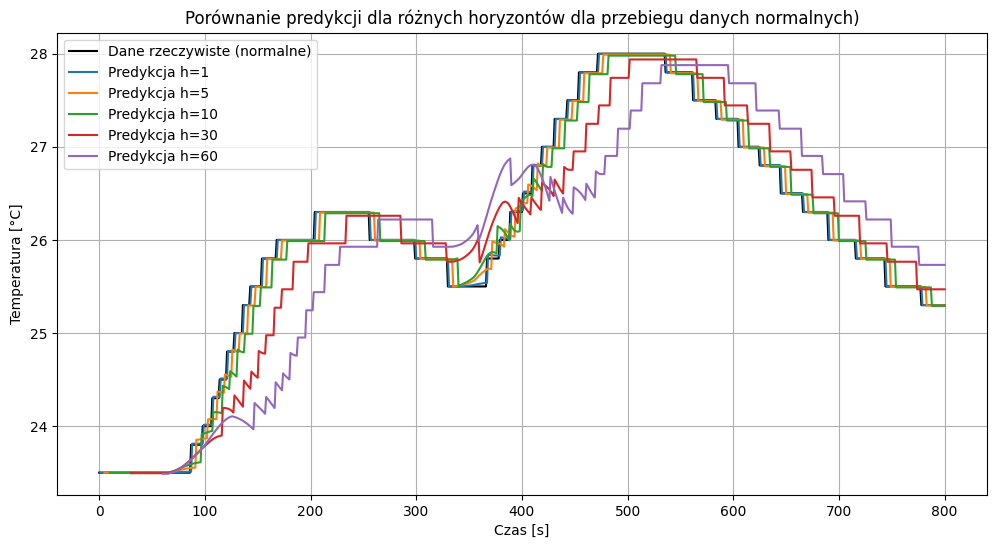

In [114]:
# przebieg rzeczywisty i przebiegi przewidywane -wykres porównawczy predykcji
plt.figure(figsize=(12, 6))
plt.plot(y_norm, label="Dane rzeczywiste (normalne)", color='black',  linewidth=1.5)
for h in horyzonty:
    plt.plot(wyniki_predykcji[h], label=f"Predykcja h={h}")
plt.title("Porównanie predykcji dla różnych horyzontów dla przebiegu danych normalnych)")
plt.xlabel("Czas [s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()

Dla h równego 1 widać dobre pokrycie, prawie idealne dopasowania z tego powodu, że predykcja tylko o 1 próbkę w przód. Przy h=5 widać pierwsze delikatne odchylenia od danych normalnych. 

DLa h = 10 zaczyna się kumulacja błedów, odchylenie w czasie jest większe - przez co bardziej widoczne na wykresie. Natomiast wciąż dobrze odwzorowuje zmiany temperturowe. 

dla h = 30 widać znaczne odchylenie oraz brak poprawnego odwzorowania na przykład w trakcie grzania 380 sekundzie widać znaczną różnice w zachowaniu predykowanych danych w stosunku do danych normalnych. 

dla h=60 - dużym horyzoncie predykcji można zauwazyć znaczną różnicę między przebiegiem rzeczywistym a przebiegiem przewidywanym - między innymi w t = 380 predykowane wygładza wykres?

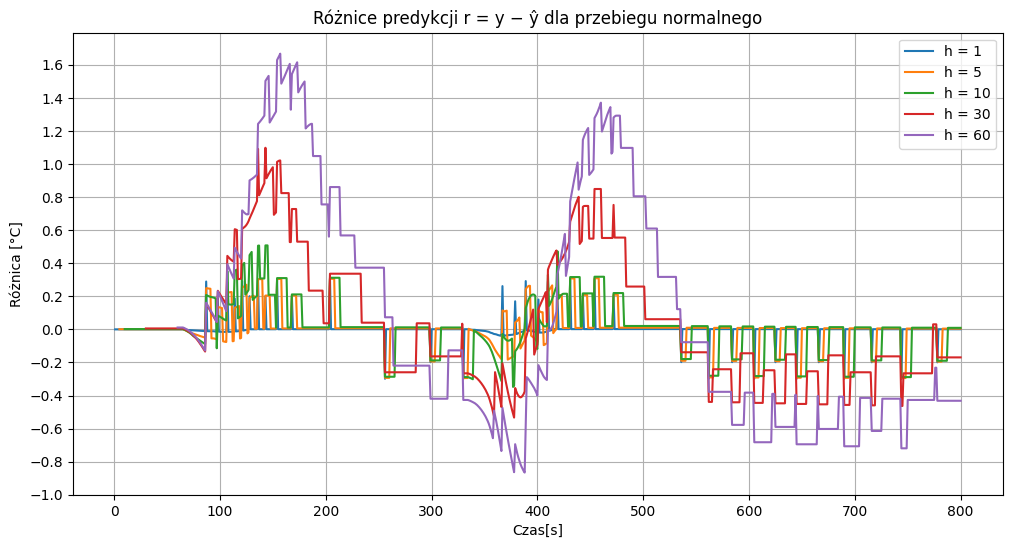

In [115]:
# CZĘŚĆ (ii)
# --- Zad.1: reszty dla przebiegu normalnego -------------------------------
reszty_normalne = {}

for h in horyzonty:
    y_pred = wyniki_predykcji[h]
    reszty_normalne[h] = y_norm - y_pred

plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_normalne[h], label=f"h = {h}")
plt.title("Różnice predykcji r = y − ŷ dla przebiegu normalnego")
plt.xlabel("Czas[s]")
plt.yticks(np.arange(-1, 1.8, 0.2))
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()

Wykres przebiegu rn - różnicy rzeczywistej wartości wyjścia od przewidywanej wartości wyjścia. Widocznie obrazuje okresy czasu, w których predykowane wartości są zawyżane - rekorody poniżej wartości 0.0 na osi Różnicy lub zaniżane - rekorody powyżej wartości 0.0 na osi Różnicy.

Dla małego horyzontu predykcji (h=1) różnica jest nieduża (dla h=1 różnica wynosi maksymalnie 0.3°C - małe kroki powodują małe błędy ponieważ model jest cały czas korygowany pomiarem.

Dla h=5 również różnica jest niewielka jednak odchylenia są bardziej widoczne ponieważ korekta jest co 5 próbek (sekund).
Dla h=10 - dłuższy brak korzystania z danych rzeczywistych sprawia, że wartość różnicy dochodzi do wartości 0.5°C - natomiast przy dłuższych okresach czasu występowania jednakowej temperatury przebieg przewidywany stara się upodobnić do przebiegu rzeczywistego
Dla h=30 - niekorzystanie przez 30s z rzeczywistych pomiarów y  sprawia, że przebieg przewidywany ma problem z pokrywaniem się z przebiegiem rzeczywistym - w pojedynczych momentach różnica wynosi ponad 1.1°C. Przebieg przewidywany jedynie kilka razy był w stanie doprowadzić do różnicy równej 0. 
Dla h=60 - tak długi horyzont predykcji odpowiada całym epizodom grzania przez co różnice przebiegu przewidywanego z rzeczywistym jest duża - może wynosić momentami ponad 1.6°C. 




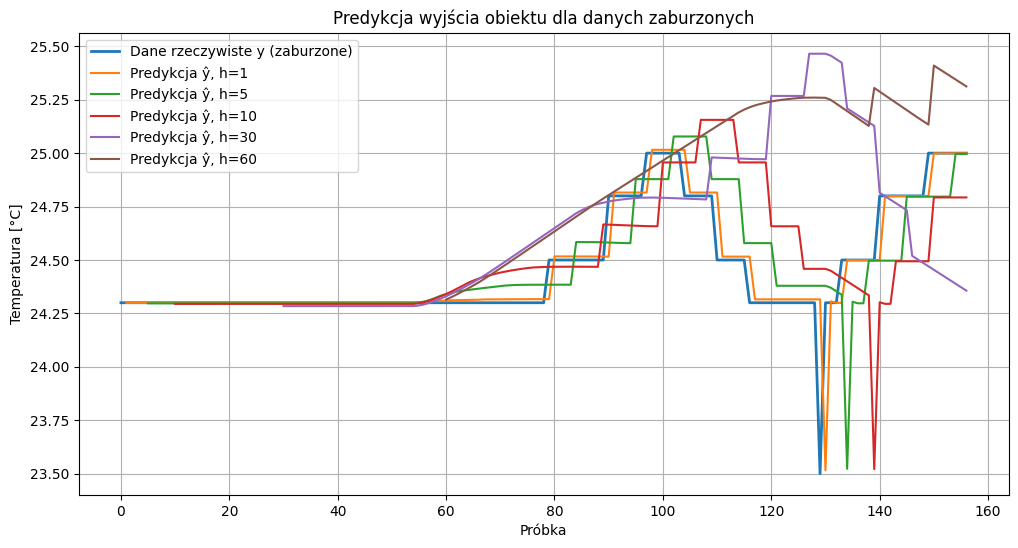

In [116]:
# Zad.2: predykcja dla danych zaburzonych - dużo mniej próbek - tylko 157 gdzie w normalnym wynosiła ponad 800
predykcje_zaburzone = {}
reszty_zaburzone = {}

for h in horyzonty:
    y_pred_zab = oblicz_predykcje(y_zab, u_zab, z_zab, a_mnk, b_mnk, h)
    predykcje_zaburzone[h] = y_pred_zab
    reszty_zaburzone[h] = y_zab - y_pred_zab
    

plt.figure(figsize=(12, 6))
plt.plot(y_zab, label="Dane rzeczywiste y (zaburzone)", linewidth=2)

for h in horyzonty:
    plt.plot(predykcje_zaburzone[h], label=f"Predykcja ŷ, h={h}")

plt.title("Predykcja wyjścia obiektu dla danych zaburzonych")
plt.xlabel("Próbka")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()


dla h=1 zaobserwowano jak w przypadku danych normalnych, że tak mały horyzont predykcji sprawia, że cały czas wykorzystywane są pomiary bardzo bliskie aktualnym. Kształt wykresu jest niemal identyczny jak w przypadku danych rzeczywistych, jedynie lekko przesunięty.

dla h=5 widać pierwsze odchylenie - w 60 sekundzie - przebieg przewidywany zakładał wzrost temperatury w związku z rozpoczęciem zwiększenia mocy grzałki. Kształt wykresu pomimo tego jest wciąż podbny do przebiegu rzeczywistego.

dla h=10 odchylenie od przebiegu rzeczywistego jest większe, w niektórych okresach czasu przebieg przewiduje nieco inne ułożenie skoku. 

dla h=30 predykowany przebieg znaczanie różni się od przebiegu rzeczywistego, ponieważ przez 30 sekund - czyli prawie 20% czasu pomiarów, nie ma żadnej korekty. W związku z taką wartością horyzontu predykcji okres czasu, w którym wentylator został włączony (wynoszący 18 sekund) może nie zostać wykorzystany w aktualizacji pomiarów. 

dla h=60 dla horyzontu predycji stanowiącego- horyzontu predykcji stanowiącego połowę czasu pomiarów zaobserwowano bardzo duży wzrost temperatury niepokrywający się z rzeczywistym przebiegiem - taka wartość h jest nieodpowiednia dla przebiegu o tak krótkim czasie. 

Warto zwrócić uwagę na to, że długości horyzontu predykcji mają takie same wartości dla obu analizowanych przebiegów - przebiegów normalnym oraz zaburzonym. Jednak ich stosunek do liczby próbek jest inny. Utrudnia to dokładne porównanie dla tych przebiegów.   

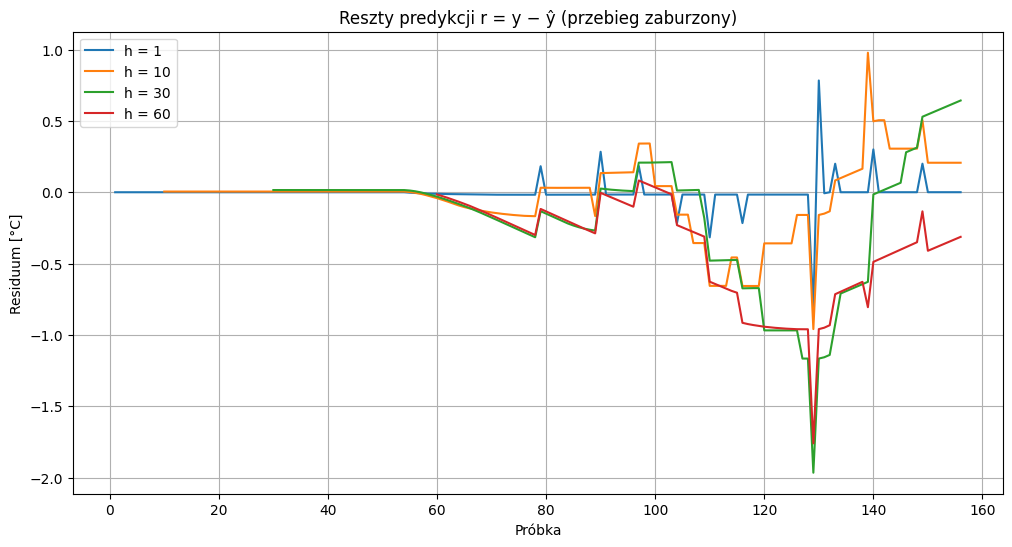

In [17]:
#Zad.3: reszty dla przebiegu zaburzonego
plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_zaburzone[h], label=f"h = {h}")
plt.title("Reszty predykcji r = y − ŷ (przebieg zaburzony)")
plt.xlabel("Próbka")
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()


--- Progi detekcji ε dla różnych horyzontów ---
h =  1: sigma = 0.0531 °C, epsilon = 0.1593 °C
h = 10: sigma = 0.1614 °C, epsilon = 0.4842 °C
h = 30: sigma = 0.3682 °C, epsilon = 1.1047 °C
h = 60: sigma = 0.6764 °C, epsilon = 2.0292 °C


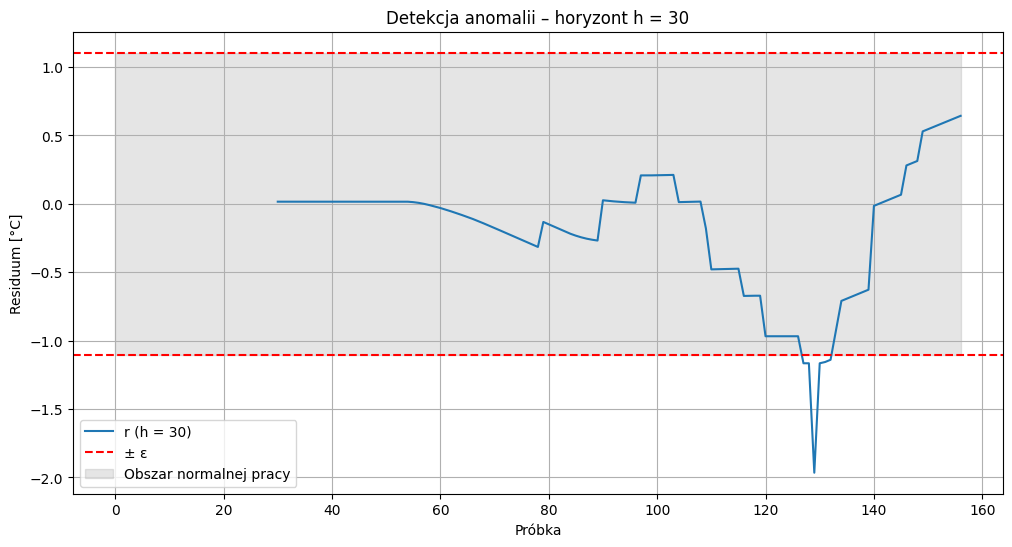

In [23]:
# --- Zad.4: wyznaczenie progów detekcji ε ----------------------------------
print("\n--- Progi detekcji ε dla różnych horyzontów ---")

progi_epsilon = {}

for h in horyzonty:
    sigma = np.nanstd(reszty_normalne[h])
    epsilon = 3 * sigma
    progi_epsilon[h] = epsilon

    print(f"h = {h:2d}: sigma = {sigma:.4f} °C, epsilon = {epsilon:.4f} °C")


# --- Wizualizacja detekcji (przykład: h = 30) ------------------------------
h_demo = 30
epsilon_demo = progi_epsilon[h_demo]

plt.figure(figsize=(12, 6))
plt.plot(reszty_zaburzone[h_demo], label=f"r (h = {h_demo})")
plt.axhline(epsilon_demo, linestyle='--', label="± ε", color = "red")
plt.axhline(-epsilon_demo, linestyle='--', color = "red")
plt.fill_between(range(len(reszty_zaburzone[h_demo])),
                 -epsilon_demo, epsilon_demo, alpha=0.2,
                 label="Obszar normalnej pracy", color = "gray")

plt.title(f"Detekcja anomalii – horyzont h = {h_demo}")
plt.xlabel("Próbka")
plt.ylabel("Residuum [°C]")
plt.legend()
plt.grid(True)
plt.show()


--- ZADANIE 5: Analiza statystyczna residuów ---
h =  1 | μ = +0.00083 °C | σ = 0.05310 °C | 3σ = 0.15930 °C
h = 10 | μ = +0.00831 °C | σ = 0.16140 °C | 3σ = 0.48420 °C
h = 30 | μ = +0.02682 °C | σ = 0.36824 °C | 3σ = 1.10471 °C
h = 60 | μ = +0.06133 °C | σ = 0.67640 °C | 3σ = 2.02919 °C


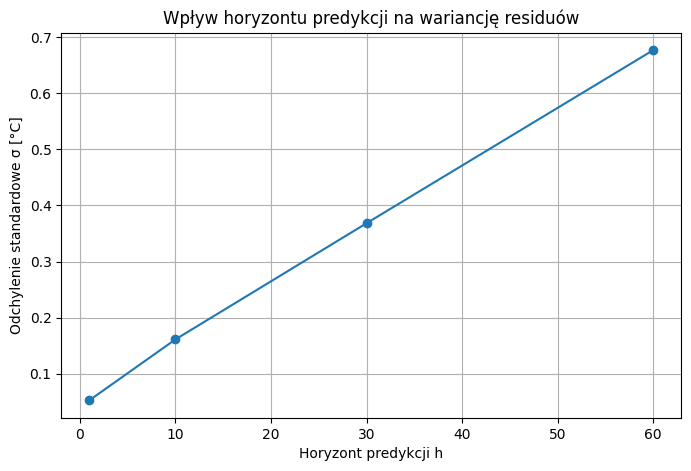

In [14]:
# =============================================================================
# ZADANIE 5 – ANALIZA STATYSTYCZNA RESIDUÓW
# =============================================================================

print("\n--- ZADANIE 5: Analiza statystyczna residuów ---")

wyniki_statystyczne = {}

for h in horyzonty:
    r = reszty_normalne[h]

    mu = np.nanmean(r)
    sigma = np.nanstd(r)

    wyniki_statystyczne[h] = {
        "mu": mu,
        "sigma": sigma,
        "prog_1sigma": sigma,
        "prog_3sigma": 3 * sigma
    }

    print(f"h = {h:2d} | μ = {mu:+.5f} °C | σ = {sigma:.5f} °C | 3σ = {3*sigma:.5f} °C")


# --- Wykres: wpływ h na σ -----------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    list(wyniki_statystyczne.keys()),
    [wyniki_statystyczne[h]["sigma"] for h in horyzonty],
    marker='o'
)
plt.xlabel("Horyzont predykcji h")
plt.ylabel("Odchylenie standardowe σ [°C]")
plt.title("Wpływ horyzontu predykcji na wariancję residuów")
plt.grid(True)
plt.show()


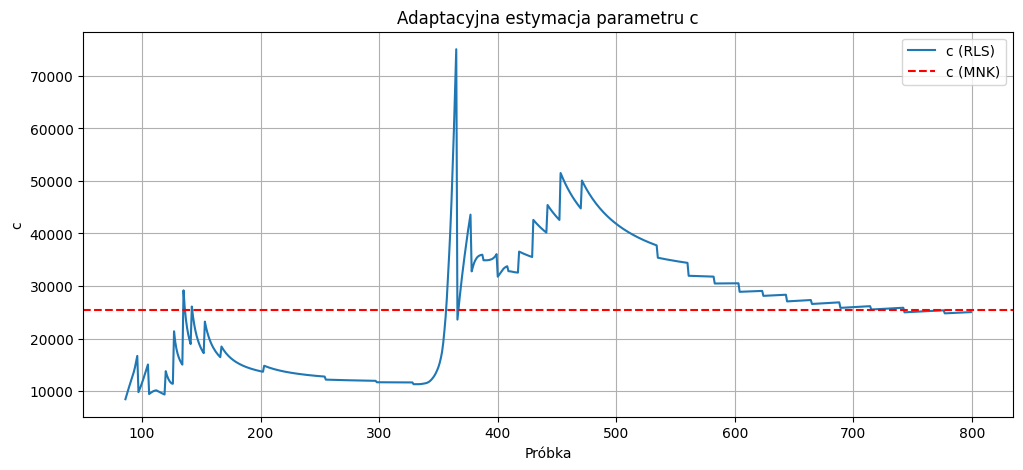

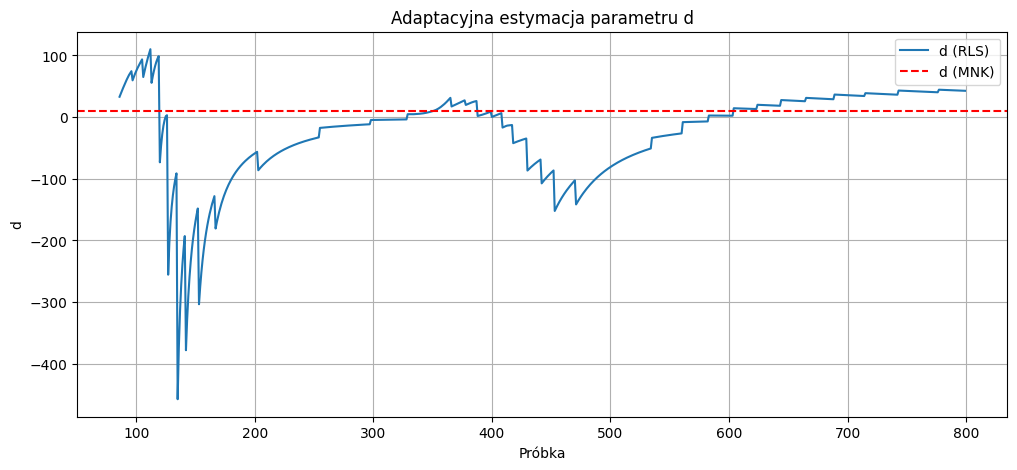

In [20]:
# =============================================================================
# ZADANIE 6 – ADAPTACYJNA IDENTYFIKACJA PARAMETRÓW (RLS)
# =============================================================================

def rls_identyfikacja(u, y, z, dt, lambda_f=0.995):
    N = len(y)

    # Inicjalizacja
    theta = np.zeros(2)               # [a, b]
    P = np.eye(2) * 1000.0             # macierz kowariancji

    historia_c = np.zeros(N-1)
    historia_d = np.zeros(N-1)

    for n in range(N - 1):
        phi = np.array([u[n], z[n] - y[n]])
        y_model = y[n+1] - y[n]

        # RLS
        K = P @ phi / (lambda_f + phi.T @ P @ phi)
        blad = y_model - phi.T @ theta
        theta = theta + K * blad
        P = (P - np.outer(K, phi) @ P) / lambda_f

        a_hat, b_hat = theta

        if abs(a_hat) > 1e-8:
            historia_c[n] = dt / a_hat
            historia_d[n] = b_hat / a_hat
        else:
            historia_c[n] = np.nan
            historia_d[n] = np.nan

    return historia_c, historia_d


# --- Uruchomienie algorytmu ----------------------------------------------
c_rls, d_rls = rls_identyfikacja(u_norm, y_norm, z_norm, dt)

# --- Wykresy --------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(c_rls, label="c (RLS)")
plt.axhline(c_wynik, linestyle='--', label="c (MNK)", color = "red")
plt.xlabel("Próbka")
plt.ylabel("c")
plt.title("Adaptacyjna estymacja parametru c")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(d_rls, label="d (RLS)")
plt.axhline(d_wynik, linestyle='--', label="d (MNK)", color = "red")
plt.xlabel("Próbka")
plt.ylabel("d")
plt.title("Adaptacyjna estymacja parametru d")
plt.legend()
plt.grid(True)
plt.show()
